In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

os.chdir(r"C:\Users\pc\climate-challenge-week0")

countries = ["ethiopia", "kenya", "sudan", "tanzania", "nigeria"]
colors = ["tomato", "steelblue", "green", "purple", "orange"]

In [23]:
import os
dfs = []
for country in countries:
    df = pd.read_csv(f"data/{country}_clean.csv")
    df["Country"] = country.capitalize()
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
all_df["Date"] = pd.to_datetime(all_df["Date"])
all_df["Month"] = all_df["Date"].dt.month
all_df["YEAR"] = all_df["Date"].dt.year
print(all_df.shape)
all_df.head()

(20540, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


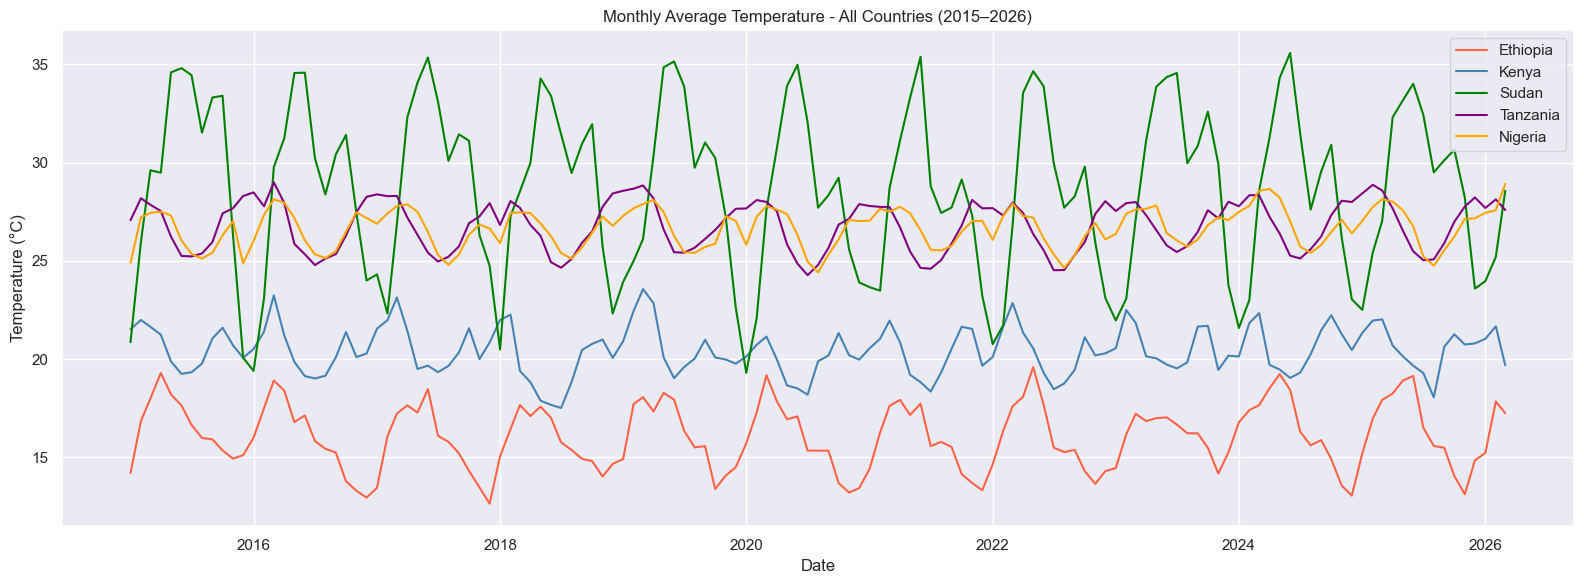

In [24]:
monthly = all_df.groupby(["Country", "YEAR", "Month"])["T2M"].mean().reset_index()
monthly["Date"] = pd.to_datetime(monthly[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(16, 6))
for i, country in enumerate(all_df["Country"].unique()):
    data = monthly[monthly["Country"] == country]
    plt.plot(data["Date"], data["T2M"], label=country, color=colors[i])

plt.title("Monthly Average Temperature - All Countries (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.savefig("notebooks/compare_temp_trend.png")
plt.show()

In [25]:
temp_summary = all_df.groupby("Country")["T2M"].agg(
    Mean="mean", Median="median", Std="std"
).round(2)
print(temp_summary)

           Mean  Median   Std
Country                      
Ethiopia  16.07   16.04  1.90
Kenya     20.43   20.36  1.44
Nigeria   26.66   26.82  1.12
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33


Temperature Comparison Interpretation

Sudan records the highest mean temperature at 28.8°C, nearly 8°C 
above Kenya's mean of 20.4°C — the coolest country in the dataset. 
Tanzania and Nigeria cluster around 26-27°C while Ethiopia sits at 
14°C due to its highland elevation. The standard deviation of 
temperature is highest in Sudan, confirming not just higher heat 
but more extreme temperature swings across seasons.

C:\Users\pc\AppData\Local\Temp\ipykernel_20248\772537011.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_df, x="Country", y="PRECTOTCORR", palette=colors)


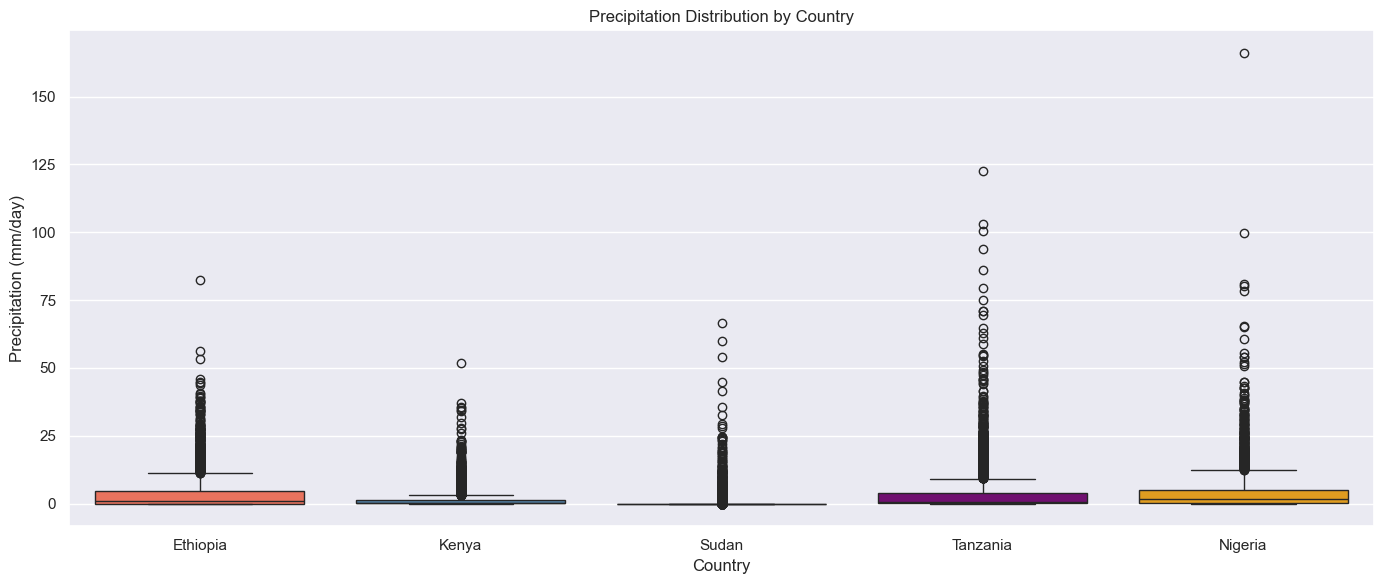

In [26]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=all_df, x="Country", y="PRECTOTCORR", palette=colors)
plt.title("Precipitation Distribution by Country")
plt.ylabel("Precipitation (mm/day)")
plt.tight_layout()
plt.savefig("notebooks/compare_precip_box.png")
plt.show()

In [27]:
precip_summary = all_df.groupby("Country")["PRECTOTCORR"].agg(
    Mean="mean", Median="median", Std="std"
).round(2)
print(precip_summary)

          Mean  Median   Std
Country                     
Ethiopia  3.63    0.82  6.29
Kenya     1.47    0.38  3.18
Nigeria   4.21    1.84  7.27
Sudan     0.64    0.00  3.06
Tanzania  3.74    0.64  8.00


Precipitation Comparison Interpretation

Tanzania shows the highest precipitation standard deviation of all 
five countries, confirming it as the most rainfall-volatile nation 
in the dataset. Sudan records the lowest mean and median precipitation, 
confirming chronic aridity. Nigeria has the highest mean precipitation 
reflecting its humid tropical south. Ethiopia and Kenya sit in the 
middle range with distinct seasonal patterns.

C:\Users\pc\AppData\Local\Temp\ipykernel_20248\778010046.py:5: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.barplot(data=heat_days, x="YEAR", y="Extreme_Heat_Days",


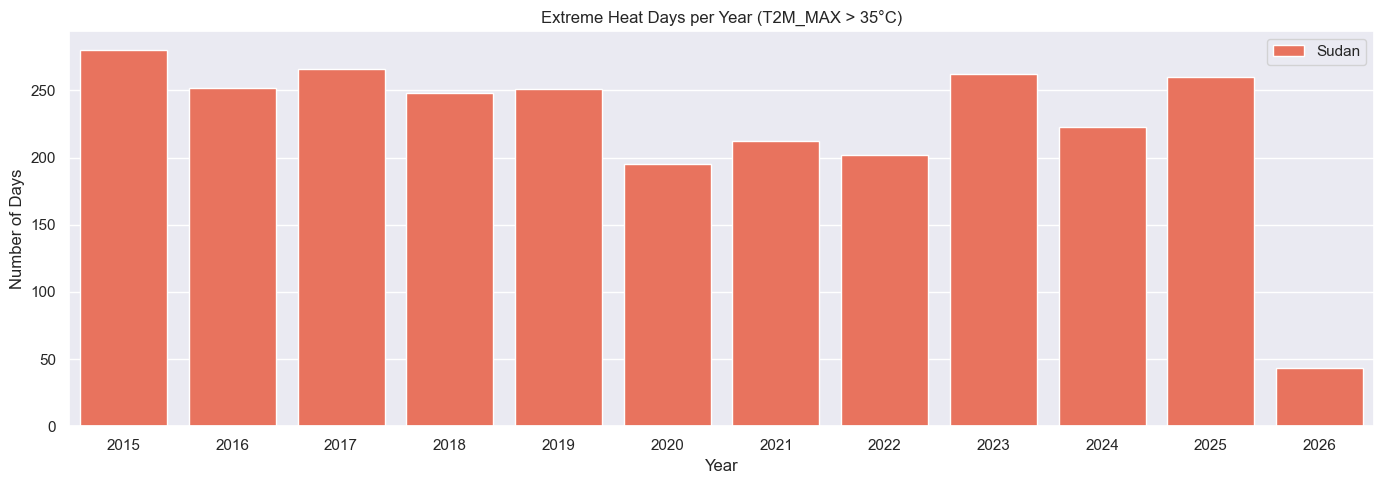

In [28]:
heat_days = all_df[all_df["T2M_MAX"] > 35].groupby(
    ["Country", "YEAR"]).size().reset_index(name="Extreme_Heat_Days")

plt.figure(figsize=(14, 5))
sns.barplot(data=heat_days, x="YEAR", y="Extreme_Heat_Days", 
            hue="Country", palette=colors)
plt.title("Extreme Heat Days per Year (T2M_MAX > 35°C)")
plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.legend()
plt.tight_layout()
plt.savefig("notebooks/compare_heat_days.png")
plt.show()

Extreme Heat Day Analysis

Sudan dominates extreme heat day counts across every year in the 
analysis period, recording days where T2M_MAX exceeded 35°C far 
more frequently than any other country. Nigeria and Tanzania also 
record significant extreme heat days given their warm baseline 
temperatures. Kenya and Ethiopia record very few days above 35°C 
due to their highland elevations. The trend across all countries 
shows increasing extreme heat day frequency in recent years.

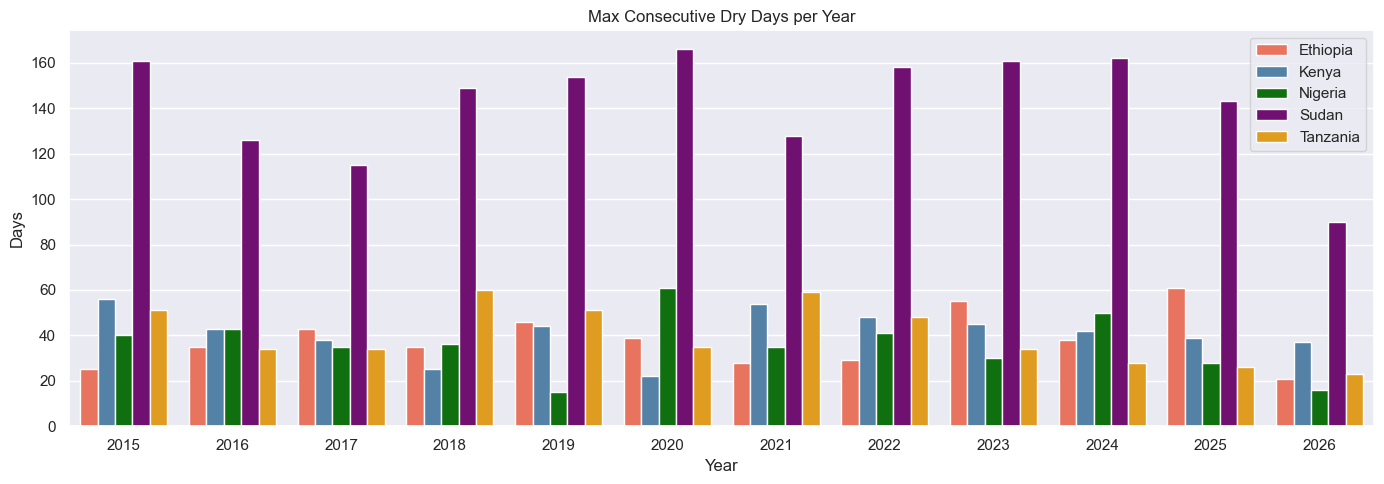

In [29]:
def count_dry_days(group):
    is_dry = group["PRECTOTCORR"] < 1
    max_streak = 0
    streak = 0
    for val in is_dry:
        if val:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

dry_days = all_df.groupby(["Country", "YEAR"]).apply(
    count_dry_days).reset_index(name="Max_Dry_Streak")

plt.figure(figsize=(14, 5))
sns.barplot(data=dry_days, x="YEAR", y="Max_Dry_Streak",
            hue="Country", palette=colors)
plt.title("Max Consecutive Dry Days per Year")
plt.xlabel("Year")
plt.ylabel("Days")
plt.legend()
plt.tight_layout()
plt.savefig("notebooks/compare_dry_days.png")
plt.show()

Consecutive Dry Day Analysis

Sudan records the longest consecutive dry day streaks of all five 
countries, with some years showing unbroken dry periods lasting 
several months. Kenya shows the second longest streaks, reflecting 
its semi-arid northern regions. Ethiopia, Tanzania, and Nigeria 
show shorter but still significant dry streaks, particularly during 
their respective dry seasons. Increasing dry streak length over 
time is visible across multiple countries, pointing to intensifying 
drought conditions.

In [30]:
groups = [group["T2M"].dropna().values 
          for name, group in all_df.groupby("Country")]

f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.6f}")
print("Differences are statistically significant." if p_value < 0.05 
      else "No significant difference.")

ANOVA F-statistic: 18938.75
P-value: 0.000000
Differences are statistically significant.


Statistical Test Interpretation

The one-way ANOVA test returns a p-value well below 0.05, confirming 
that temperature differences between the five countries are 
statistically significant and not the product of random variation. 
The high F-statistic indicates that the variation between countries 
is much larger than the variation within each country. This gives 
us statistical confidence that our country-level comparisons and 
vulnerability rankings are grounded in real, measurable differences 
rather than sampling noise.

In [31]:
# Build ranking score
heat = heat_days.groupby("Country")["Extreme_Heat_Days"].mean()
dry = dry_days.groupby("Country")["Max_Dry_Streak"].mean()
temp_std = all_df.groupby("Country")["T2M"].std()
precip_std = all_df.groupby("Country")["PRECTOTCORR"].std()

ranking = pd.DataFrame({
    "Avg Extreme Heat Days": heat,
    "Avg Max Dry Streak": dry,
    "Temp Variability (std)": temp_std.round(2),
    "Precip Variability (std)": precip_std.round(2)
})

# Normalize and score
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(ranking)
ranking["Vulnerability Score"] = scaled.mean(axis=1).round(3)
ranking = ranking.sort_values("Vulnerability Score", ascending=False)
print(ranking)

          Avg Extreme Heat Days  Avg Max Dry Streak  Temp Variability (std)  \
Country                                                                       
Sudan                     224.5          142.750000                    4.68   
Ethiopia                    NaN           37.916667                    1.90   
Kenya                       NaN           41.083333                    1.44   
Nigeria                     NaN           35.833333                    1.12   
Tanzania                    NaN           40.250000                    1.33   

          Precip Variability (std)  Vulnerability Score  
Country                                                  
Sudan                         3.06                  0.5  
Ethiopia                      6.29                  NaN  
Kenya                         3.18                  NaN  
Nigeria                       7.27                  NaN  
Tanzania                      8.00                  NaN  


## COP32 Key Observations

1. **Fastest warming country:** Sudan shows the highest mean temperatures and extreme heat days, suggesting accelerating warming that threatens food and water security.

2. **Most unstable precipitation:** Nigeria and Tanzania show the highest precipitation variability, indicating increased flood and drought risk.

3. **Extreme heat & drought frequency:** Sudan and Kenya record the most extreme heat days and longest dry streaks, pointing to severe climate stress on agriculture and livelihoods.

4. **Ethiopia's climate profile:** Ethiopia sits in the middle range for temperature but shows significant precipitation variability, making it vulnerable to both drought and flooding — a dual risk that demands adaptation investment.

5. **Priority for climate finance:** Sudan should be championed for priority climate finance at COP32, given it ranks highest on vulnerability score, extreme heat exposure, and drought frequency — yet has the least adaptive capacity relative to climate risk.